In [1]:
import serial
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

Capture

END


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

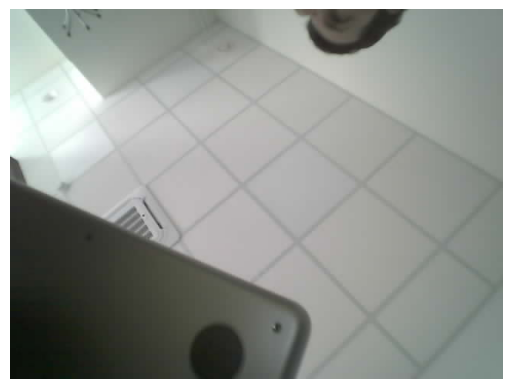

In [25]:
ser = serial.Serial("/dev/cu.usbserial-110", 115200, timeout=10)

ser.write(b"u")
line = ser.readline().decode(errors="ignore").strip()
while not line.startswith("IMG "):
    print(line)
    line = ser.readline().decode(errors="ignore").strip()

size = int(line.split()[1])
jpg = ser.read(size)

# consume trailing newline + END line
print(ser.readline().decode(errors="ignore").strip())
print(ser.readline().decode(errors="ignore").strip())

img = Image.open(BytesIO(jpg))
plt.imshow(img)
plt.axis("off")